# Stackoverflow Data Diving 🤿

Finding insights in StackOverflow's Developer Survey data.

**survey_results_public_2021_ds.csv** is Stackoverflow Developer Survey 2021 ([Open Database License](https://opendatacommons.org/licenses/odbl/1.0/)), filtered down respondents that self-identified as data scientists.

## What could be explored? 🗺️

Pick one and explore it!

- What types of roles should be covered as Data Science related?
- When data scientists get stuck at work, does it help to go for a walk?
- What editors do Data Scientists use?
- New vs experienced data scientists?
  - Difference in editors, tools, and platforms.
- What other roles do devs who do data science have?
- Are all data science tools reflected in roles (compared to usage of DS tools)?

In [1]:
import pandas as pd
import seaborn as sns

In [2]:
# pandas and seaborn options
sns.set_style("whitegrid")
pd.set_option('mode.chained_assignment', None)

## Explore and clean the data 🧹

Load up the survey data and try to make sense of it.

In [3]:
df = pd.read_csv('datasets/survey_results_public_2021_ds.csv')

In [4]:
df.head()

,Unnamed: 0,ResponseId,MainBranch,Employment,Country,US_State,UK_Country,EdLevel,Age1stCode,LearnCode,...,Age,Gender,Trans,Sexuality,Ethnicity,Accessibility,MentalHealth,SurveyLength,SurveyEase,ConvertedCompYearly
0,9,10,I am a developer by profession,Employed full-time,Sweden,NaN,NaN,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",11 - 17 years,School,...,25-34 years old,Man,No,Straight / Heterosexual,White or of European descent,None of the above,None of the above,Appropriate in length,Neither easy nor difficult,"$51,552"
1,13,14,I am a student who is learning to code,Employed full-time,Peru,NaN,NaN,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",5 - 10 years,School,...,Prefer not to say,Prefer not to say,Prefer not to say,Prefer not to say,Prefer not to say,Prefer not to say,Prefer not to say,Too long,Neither easy nor difficult,NaN
2,23,24,I am a developer by profession,Employed full-time,France,NaN,NaN,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",11 - 17 years,School;Online Courses or Certification,...,25-34 years old,Man,No,NaN,White or of European descent,None of the above,None of the above,Appropriate in length,Neither easy nor difficult,"$38,915"
3,58,59,"I am not primarily a developer, but I write co...",Employed full-time,Russian Federation,NaN,NaN,"Professional degree (JD, MD, etc.)",11 - 17 years,"Other online resources (ex: videos, blogs, etc...",...,25-34 years old,Man,No,Straight / Heterosexual,White or of European descent,None of the above,None of the above,Appropriate in length,Easy,"$22,644"
4,62,63,"I am not primarily a developer, but I write co...",Employed full-time,United States of America,New York,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",11 - 17 years,Online Forum,...,25-34 years old,Man,No,Straight / Heterosexual,NaN,NaN,I have a concentration and/or memory disorder ...,Appropriate in length,Easy,"$130,000"


In [6]:
"""
Cell generated by Data Wrangler.
"""
def clean_data(df):
    # Select columns: 'YearsCodePro', 'NEWStuck', 'ConvertedCompYearly'
    df = df[['YearsCodePro', 'NEWStuck', 'ConvertedCompYearly']]
    # Drop rows with missing data in columns: 'YearsCodePro', 'ConvertedCompYearly'
    df.dropna(subset=['YearsCodePro', 'ConvertedCompYearly'], inplace=True)
    # Derive column 'CompYearly' from column: 'ConvertedCompYearly'
    def CompYearly(ConvertedCompYearly):
        """
        Transform "ConvertedCompYearly" as per the following examples:
          $51,552 ==> 51552
        """
        number1 = float(ConvertedCompYearly.split("$")[-1].replace(",", ""))
        return f"{number1:01.0f}"
    
    df.insert(3, "CompYearly", df.apply(lambda row : CompYearly(row["ConvertedCompYearly"]), axis=1))
    # Drop column: 'ConvertedCompYearly'
    df.drop(columns=['ConvertedCompYearly'], inplace=True)
    # Multi-label encode column 'NEWStuck' using delimiter ';'
    loc_0 = df.columns.get_loc('NEWStuck')
    df_encoded = df['NEWStuck'].str.get_dummies(sep=';').add_prefix('NEWStuck_')
    df = pd.concat([df.iloc[:,:loc_0], df_encoded, df.iloc[:,loc_0+1:]], axis=1)
    # Select columns: 'YearsCodePro', 'NEWStuck_Go for a walk or other physical activity', 'CompYearly'
    df = df[['YearsCodePro', 'NEWStuck_Go for a walk or other physical activity', 'CompYearly']]
    # Change column type to int64 for column: 'CompYearly'
    df = df.astype({'CompYearly': 'int64'}, copy=False)
    # Filter rows based on column: 'CompYearly'
    df = df[df['CompYearly'] < 300000]
    return df

df_clean = clean_data(df.copy())
df_clean.head()

,YearsCodePro,NEWStuck_Go for a walk or other physical activity,CompYearly
0,4.0,0,51552
2,2.0,0,38915
3,3.0,1,22644
4,5.0,1,130000
6,8.0,1,151263


## Learn from the data

Capturing all the juicy insights.

## Comparing coding experience to comp

Low hanging exploration from gleaming the data.

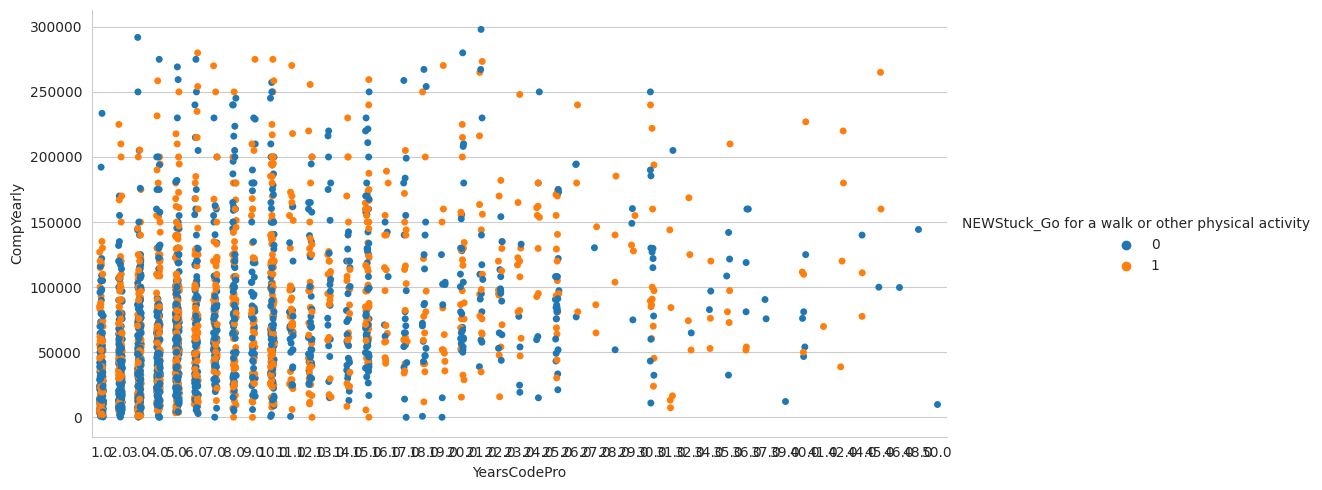

In [9]:
# Plot years of pro coding experience against total compensation
# sns.catplot(data=df_clean, x='YearsCodePro', y='CompYearly')
# same plot, but wider
# sns.catplot(data=df_clean, x='YearsCodePro', y='CompYearly', aspect=2)
# add color for the "Go for a walk" option
sns.catplot(data=df_clean, x='YearsCodePro', y='CompYearly', aspect=2, hue='NEWStuck_Go for a walk or other physical activity')

<AxesSubplot: xlabel='NEWStuck_Go for a walk or other physical activity', ylabel='CompYearly'>

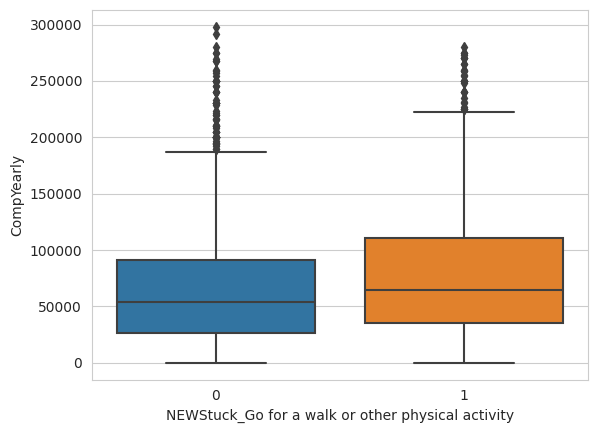

In [10]:
# boxplot to compare compensation across go for a walk vs. don't go for a walk
sns.boxplot(data=df_clean, x='NEWStuck_Go for a walk or other physical activity', y='CompYearly')

<AxesSubplot: xlabel='NEWStuck_Go for a walk or other physical activity', ylabel='YearsCodePro'>

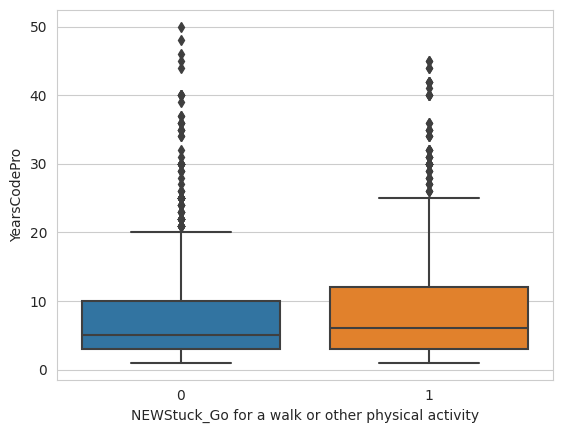

In [11]:
# same plot, but for years of pro coding experience
sns.boxplot(data=df_clean, x='NEWStuck_Go for a walk or other physical activity', y='YearsCodePro')

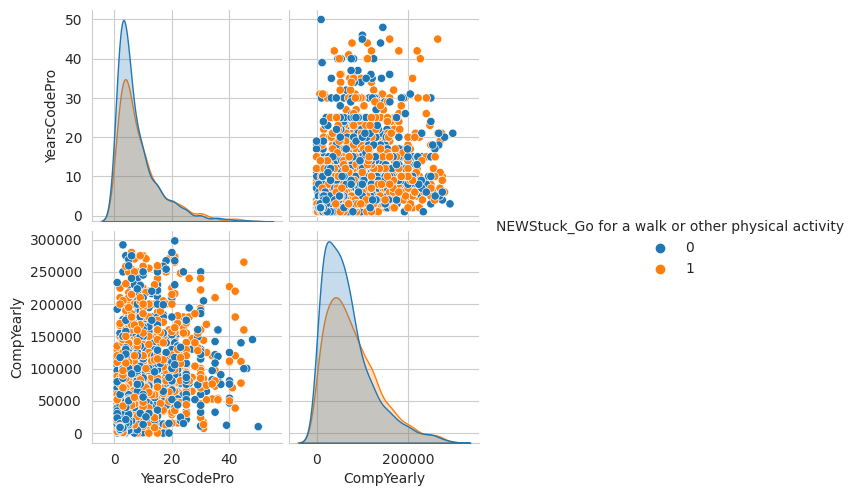

In [13]:
# pairgrid to compare compensation across go for a walk vs. don't go for a walk
# and years of pro coding experience
sns.pairplot(data=df_clean, hue='NEWStuck_Go for a walk or other physical activity')